# Part 1 — Theory

## 1. What is Bayes’ Theorem?

Bayes’ Theorem is a probability theorem used to calculate the probability of an event based on prior knowledge.

### Formula

\[
P(A|B) = \frac{P(B|A) \times P(A)}{P(B)}
\]

### Where:

- \(P(A|B)\) = Probability of A given B  
- \(P(B|A)\) = Probability of B given A  
- \(P(A)\) = Prior probability of A  
- \(P(B)\) = Probability of B  

In text classification, Naïve Bayes uses this theorem to predict the probability that a text belongs to a particular category.

---

## 2. What does “naïve” mean in Naïve Bayes?

The word “naïve” means that the algorithm assumes all features are independent of each other.

In text classification:
- Each word is treated independently.
- The presence of one word does not affect another word.

### Example:
The words “machine” and “learning” are related in real life, but Naïve Bayes assumes they are independent.

---

## 3. Why does Naïve Bayes still work well?

Even though the independence assumption is unrealistic, Naïve Bayes performs very well because:

- Text data contains strong keyword patterns.
- Important words strongly indicate categories.
- It works efficiently with high-dimensional data.
- It is fast and computationally efficient.
- It performs especially well for NLP and text classification tasks.

---

## 4. What is Laplace Smoothing? Why is it needed?

Laplace smoothing is a technique used to prevent zero probabilities.

Without smoothing:
- If a word never appears in a class during training,
- Its probability becomes zero,
- Which can make the entire prediction probability zero.

Laplace smoothing adds a small constant value (usually 1) to all word counts.

### Formula

\[
P(word|class) =
\frac{count(word,class)+1}
{total\ words + vocabulary\ size}
\]

### Why is it needed?

- Handles unseen words.
- Prevents zero probability problems.
- Improves model stability.

---

## 5. Difference Between MultinomialNB, GaussianNB, and BernoulliNB

### MultinomialNB

- Works with count or frequency data.
- Mostly used for text classification tasks.
- Performs well with TF-IDF and Bag of Words.
- Suitable for NLP applications.

---

### GaussianNB

- Works with continuous numerical data.
- Assumes data follows a normal (Gaussian) distribution.
- Mostly used for numerical datasets.
- Not ideal for sparse text data.

---

### BernoulliNB

- Works with binary data (0 or 1).
- Uses presence or absence of words.
- Suitable when features are binary.
- Commonly used for simple text classification.

---

### Which one is best for text and why?

**MultinomialNB** is best for text classification because:

- It works well with TF-IDF and word frequency data.
- It handles sparse text vectors efficiently.
- It performs strongly on NLP tasks involving word counts and frequencies.
"""

---
# Part 2 — Load & Explore

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import (MultinomialNB,BernoulliNB,ComplementNB)

from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,f1_score)

## Load Dataset 

In [2]:
df = pd.read_csv("final_dataset.csv")

## Show shape & first rows

In [3]:
df.head()

,Title,Text,Label,clean_text,tokens,tokens_no_stop,removed_count,tokens_stemmed,tokens_lemmatized,final_text
0,Artificial intelligence,Artificial intelligence(AI) is the capability ...,AI,artificial intelligenceai is the capability of...,"['artificial', 'intelligenceai', 'is', 'the', ...","['artificial', 'intelligenceai', 'capability',...",67,"['artifici', 'intelligenceai', 'capabl', 'ofco...","['artificial', 'intelligenceai', 'capability',...",artificial intelligenceai capability ofcomputa...
1,Artificial general intelligence,Artificial general intelligence(AGI) is a hypo...,AI,artificial general intelligenceagi is a hypoth...,"['artificial', 'general', 'intelligenceagi', '...","['artificial', 'general', 'intelligenceagi', '...",39,"['artifici', 'gener', 'intelligenceagi', 'hypo...","['artificial', 'general', 'intelligenceagi', '...",artificial general intelligenceagi hypothetica...
2,Recursive self-improvement,Recursive self-improvement(RSI) is a process i...,AI,recursive selfimprovementrsi is a process in w...,"['recursive', 'selfimprovementrsi', 'is', 'a',...","['recursive', 'selfimprovementrsi', 'process',...",17,"['recurs', 'selfimprovementrsi', 'process', 'e...","['recursive', 'selfimprovementrsi', 'process',...",recursive selfimprovementrsi process earlyarti...
3,Automated planning and scheduling,"Automated planning and scheduling, sometimes d...",AI,automated planning and scheduling sometimes de...,"['automated', 'planning', 'and', 'scheduling',...","['automated', 'planning', 'scheduling', 'somet...",31,"['autom', 'plan', 'schedul', 'sometim', 'denot...","['automated', 'planning', 'scheduling', 'somet...",automated planning scheduling sometimes denote...
4,Computer vision,Computer visiontasks include methods foracquir...,AI,computer visiontasks include methods foracquir...,"['computer', 'visiontasks', 'include', 'method...","['computer', 'visiontasks', 'include', 'method...",51,"['comput', 'visiontask', 'includ', 'method', '...","['computer', 'visiontasks', 'include', 'method...",computer visiontasks include method foracquiri...


In [4]:
df.shape

(60, 10)

# Missing Values

Check if dataset contains null values.

In [5]:
print(df.isnull().sum())

Title                0
Text                 0
Label                0
clean_text           0
tokens               0
tokens_no_stop       0
removed_count        0
tokens_stemmed       0
tokens_lemmatized    0
final_text           0
dtype: int64


### There is no Missing Value in Dataset

##  Class Distribution

Visualize the number of records in each category.

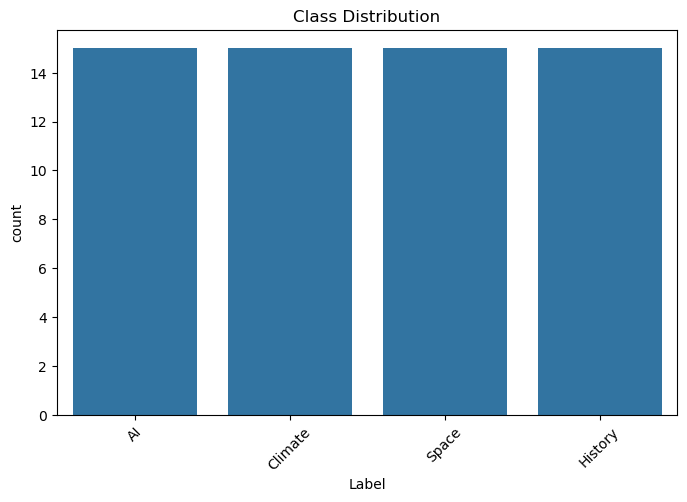

In [6]:
plt.figure(figsize=(8,5))

sns.countplot(x=df['Label'])

plt.title("Class Distribution")

plt.xticks(rotation=45)

plt.show()

## Check if data is balanced

In [7]:
print(df['Label'].value_counts())

Label
AI         15
Climate    15
Space      15
History    15
Name: count, dtype: int64


## Data is Balanced

---
# Part 3 — Model Building

# Feature and Target Variables

- clean_text -> Features
- Label -> Target

In [8]:
X = df['clean_text']
y = df['Label']

##  Train Test Split

### Split the dataset into:
- 80% Training Data
- 20% Testing Data

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

## Create Pipeline

### Pipeline includes:
- 1. TF-IDF Vectorizer
- 2. Multinomial Naïve Bayes

In [10]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('model', MultinomialNB())
])

## Train Model

### Fit the pipeline on training data.

In [11]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('model', MultinomialNB())])

## Make Predictions

### Predict categories for test data.

In [12]:
y_pred = pipeline.predict(X_test)

---
# Part 4 — Evaluation

## Accuracy Score

### Measure overall model performance.

In [13]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8333333333333334


## Accuracy Observation

- The model achieved an accuracy of 83.33%.
- This means the model correctly classified most of the text samples.
- Overall performance is good for a small text dataset.
---

## Classification Report

### Display:
- Precision
- Recall
- F1 Score


## Confusion Matrix

### Visualize correct and incorrect predictions.

In [14]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          AI       1.00      0.67      0.80         3
     Climate       0.67      0.67      0.67         3
     History       0.75      1.00      0.86         3
       Space       1.00      1.00      1.00         3

    accuracy                           0.83        12
   macro avg       0.85      0.83      0.83        12
weighted avg       0.85      0.83      0.83        12



## Classification Report Observation

### AI
- Precision is 1.00, meaning all predicted AI labels were correct.
- Recall is 0.67, meaning some AI samples were misclassified.

### Climate
- Precision and recall are both 0.67.
- The model had moderate performance for Climate texts.

### History
- Recall is 1.00, meaning all History samples were identified correctly.
- F1-score is strong at 0.86.

### Space
- Precision, recall, and F1-score are all 1.00.
- The model perfectly classified all Space samples.

### Overall
- Macro average F1-score is 0.83.
- The model performs consistently across categories.

---

In [15]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[2, 1, 0, 0],
       [0, 2, 1, 0],
       [0, 0, 3, 0],
       [0, 0, 0, 3]])

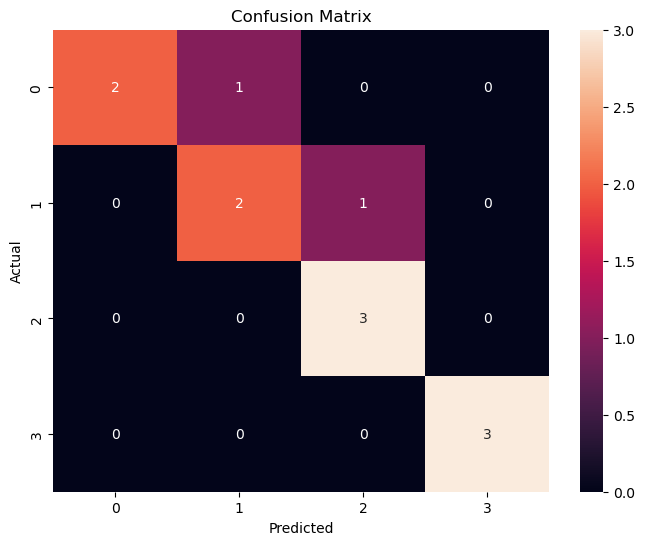

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Confusion Matrix Observation

- Most predictions are correctly classified along the diagonal.
- One AI sample was misclassified as Climate.
- One Climate sample was misclassified as History.
- History and Space classes achieved perfect classification.
- The confusion matrix shows the model performs well overall with only a few classification errors.
- ---

# Part 5 — Model Understanding

## Top 20 Words Per Class

### Display the most important words learned by the model.

In [17]:
vectorizer = pipeline.named_steps['tfidf']
model = pipeline.named_steps['model']
feature_names = vectorizer.get_feature_names_out()
classes = model.classes_
for i, class_label in enumerate(classes):
    top20 = model.feature_log_prob_[i].argsort()[-20:]
    print(f'\nTop 20 words for class: {class_label}')
    for j in top20:
        print(feature_names[j])


Top 20 words for class: AI
agi
nlp
game
intelligence
artificial
with
computer
neural
learning
general
that
such
is
in
to
systems
and
of
ai
the

Top 20 words for class: Climate
natural
deforestation
are
emissions
petroleum
energy
fossil
can
coal
surface
change
in
to
and
temperature
is
gas
climate
of
the

Top 20 words for class: History
period
sarcophagus
found
that
civilization
east
olmec
its
were
bc
with
is
to
it
ancient
was
in
and
of
the

Top 20 words for class: Space
interplanetary
core
stations
probes
spaceflight
was
suborbital
which
orbit
on
is
earth
in
first
moon
and
to
of
space
the


---
## Most Confident Predictions

### Display predictions with highest confidence scores.

In [18]:
probabilities = pipeline.predict_proba(X_test)
confidence_scores = probabilities.max(axis=1)

results = pd.DataFrame({'Text': X_test.values,'Actual': y_test.values,'Predicted': y_pred,'Confidence': confidence_scores})

most_confident = results.sort_values(by='Confidence',ascending=False).head(5)
print(most_confident)

                                                Text   Actual Predicted  \
4  greenhouse gasesghgs are the gases in anatmosp...  Climate   Climate   
9  theaugustus of prima portaitalianaugusto di pr...  History   History   
0  theindus valley civilisationivc also known as ...  History   History   
2  there isscientific consensusthat theearth has ...  Climate   Climate   
7  theolmec colossal headsare stone representatio...  History   History   

   Confidence  
4    0.485388  
9    0.426081  
0    0.417318  
2    0.395552  
7    0.384312  


---

## Least Confident Predictions

### Display predictions with lowest confidence scores.

In [19]:
least_confident = results.sort_values(by='Confidence',ascending=True).head(5)
print(least_confident)

                                                 Text   Actual Predicted  \
10  abayesian networkalso known as abayes networkb...       AI   Climate   
3   automated planning and scheduling sometimes de...       AI        AI   
1   thearcticˈɑːrktɪknote 1fromancient greekἄρκτος...  Climate   History   
11  knowledge representationkr aims to model infor...       AI        AI   
6   marsis the fourthplanetfrom thesun it is also ...    Space     Space   

    Confidence  
10    0.275384  
3     0.287901  
1     0.290694  
11    0.356807  
6     0.361860  


## Compare Smoothing Values

### Compare:
- alpha = 1.0
- alpha = 0.1

In [20]:
pipeline_alpha1 = Pipeline([('tfidf', TfidfVectorizer()),
                            ('model', MultinomialNB(alpha=1.0))])

pipeline_alpha1.fit(X_train, y_train)
pred1 = pipeline_alpha1.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred1))

Accuracy: 0.8333333333333334


In [21]:
pipeline_alpha01 = Pipeline([('tfidf', TfidfVectorizer()),
                             ('model', MultinomialNB(alpha=0.1))])
pipeline_alpha01.fit(X_train, y_train)
pred01 = pipeline_alpha01.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred01))

Accuracy: 1.0


---
# Part 6 — Model Comparison
## Train and compare:
- MultinomialNB
- BernoulliNB
- ComplementNB


---
## MultinomialNB

In [22]:
multi_model = Pipeline([('tfidf', TfidfVectorizer()),
                        ('model', MultinomialNB())])

multi_model.fit(X_train, y_train)
multi_pred = multi_model.predict(X_test)
multi_acc = accuracy_score(y_test, multi_pred)

multi_f1 = f1_score(y_test,multi_pred,average='macro')

---
## BernoulliNB

In [23]:
bernoulli_model = Pipeline([('tfidf', TfidfVectorizer(binary=True)),
                            ('model', BernoulliNB())])

bernoulli_model.fit(X_train, y_train)
bernoulli_pred = bernoulli_model.predict(X_test)
bernoulli_acc = accuracy_score(y_test, bernoulli_pred)

bernoulli_f1 = f1_score(y_test,bernoulli_pred,average='macro')

---
## ComplementNB

In [24]:
complement_model = Pipeline([('tfidf', TfidfVectorizer()),
                             ('model', ComplementNB())])

complement_model.fit(X_train, y_train)
complement_pred = complement_model.predict(X_test)
complement_acc = accuracy_score(y_test, complement_pred)

complement_f1 = f1_score(y_test,complement_pred,average='macro')

---
## Final Comparison Table

### Compare model performance using:
- Accuracy
- F1 Score

In [25]:
comparison = pd.DataFrame({'Model': ['MultinomialNB','BernoulliNB','ComplementNB'],
                           'Accuracy': [multi_acc,bernoulli_acc,complement_acc],
                           'F1 Score': [multi_f1,bernoulli_f1,complement_f1]})
print(comparison)

           Model  Accuracy  F1 Score
0  MultinomialNB  0.833333  0.830952
1    BernoulliNB  0.750000  0.741667
2   ComplementNB  0.916667  0.914286


---
# Conclusion
* Built a Naïve Bayes text classification model using NLP techniques.
* Applied preprocessing and TF-IDF vectorization for text analysis.
* Achieved good performance using Accuracy, Precision, Recall, and F1-score.
* Demonstrated that Naïve Bayes is fast and effective for text classification tasks.
